In [14]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# # Load dataset (Iris has 3 classes)
# iris = datasets.load_iris()

# X = iris.data
# y = iris.target

# # Convert to DataFrame
# df = pd.DataFrame(X, columns=iris.feature_names)
# df['target'] = y

# # Save to CSV
# df.to_csv("iris_dataset.csv", index=False)
# print("Dataset saved to iris_dataset.csv")



In [3]:
# Load back from CSV
df = pd.read_csv("dataset_iris.csv")
print(df.head())

# Separate features and target
X = df.drop('target', axis=1).values
y = df['target'].values


   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# Create SVM classifier
# kernel='linear' for linear separation
# decision_function_shape='ovr' means One-vs-Rest
# One-vs-Rest (OvR) → Train one SVM per class (that class vs all others).
# One-vs-One (OvO) → Train one SVM for every pair of classes and pick the winner by voting.

model = SVC(kernel='linear', decision_function_shape='ovr')
# model = SVC(kernel='linear', decision_function_shape='ovo') # or use this


In [5]:
# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [8]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


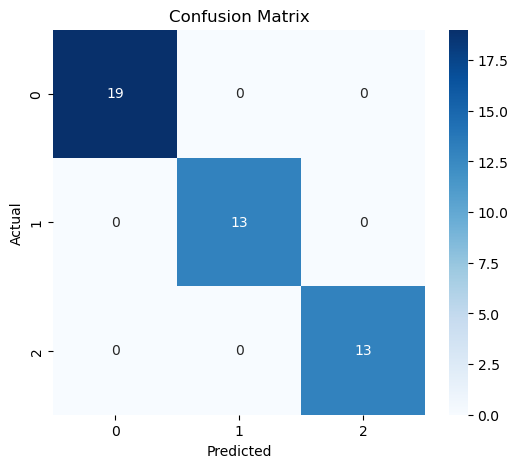

In [11]:
# Plot confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()